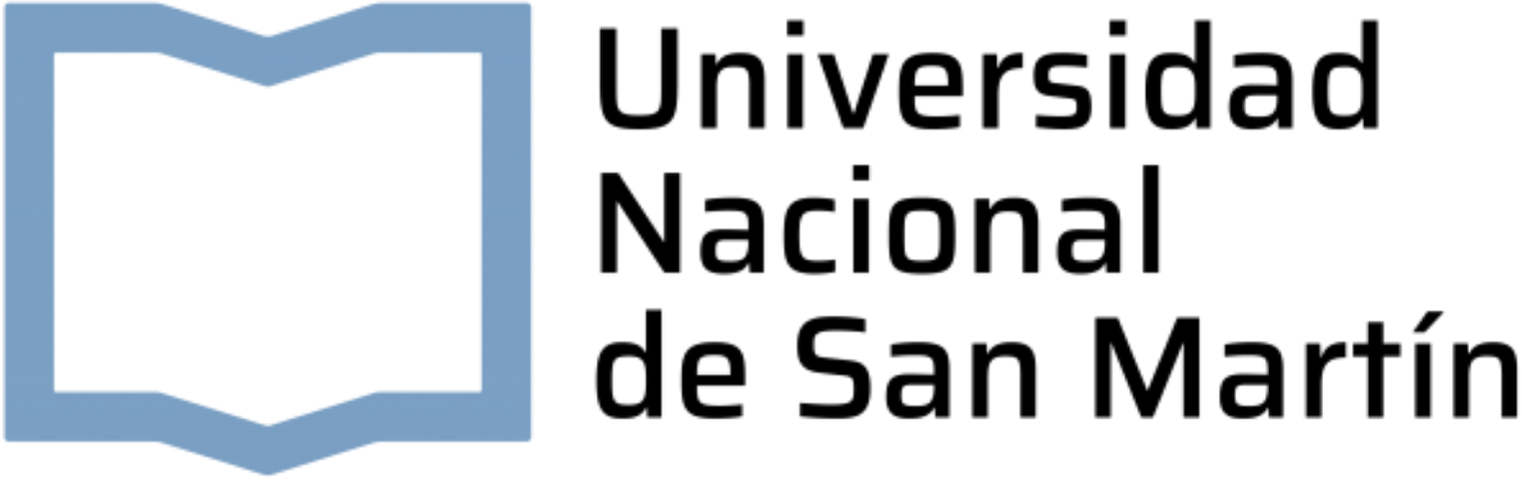


# TS0 Cristóbal Contador

**En esta practica se hizo un generador de señales en python haciendo uso de diferentes librerias y se vio el comportamiento de las señales basandonos en nuestro contexto teorico y viendo como se traduce a la realidad, a continuacion analizaremos las diferentes señales.**

Primero lo que haremos para hacer nuestro generador de señales sera dejar nuestros parametros fijos y hacer las importaciones, en este caso usaremos una fs fija de 1000hz, por lo cual se espera teoricamente que nuestro umbral de nyquist va a ser fs/2, osea 500hz. Nuestro número de muestras lo mantendremos fijo para acotar nuestras señales.

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal #esto lo pongo para las cuadradas
print("importado") #esto se lo agrego pq asi aca en el jupyter puedo ir viendo si me importo bien

#estas primeras son fijas de la experiencia
fs = 1000 #frecuencia fija
N = 1000 # muestras
print("variables fijadas")
fn = fs/2
print("frecuencia de nyquist de", fn, "hz") #esto lo agrego para poder ver bien mi valor de frecuencia de nyquist

importado
variables fijadas
frecuencia de nyquist de 500.0 hz


Luego de que ya tenemos las importaciones listas comenzaremos a definir nuestra primera funcion, la cual sera seno en primera instancia, más adelante se generaran otro tipo de señales.

In [15]:
def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    xx = (vmax * np.sin(2 * np.pi * ff * np.arange(nn)/fs + ph)) +dc
    tt = np.arange(N)/fs
    return (tt,xx)
    
print("funcion definida") #esto se lo agrego pq asi aca en el jupyter puedo ir viendo si me imprimio bien

funcion definida


Ahora agregamos nuestras variables.

In [37]:
#de aqui para abajo recien edito
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 500 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!

tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff)
print("variables aplicadas")

variables aplicadas


Ahora por ultimo agregaremos nuestros graficos, asi podemos visualizar lo que esta sucediendo

[ 0.00000000e+00  2.44929360e-16 -4.89858720e-16  7.34788079e-16
 -9.79717439e-16  4.77736048e-15 -1.46957616e-15  1.71450552e-15
 -1.95943488e-15  9.30979160e-15]


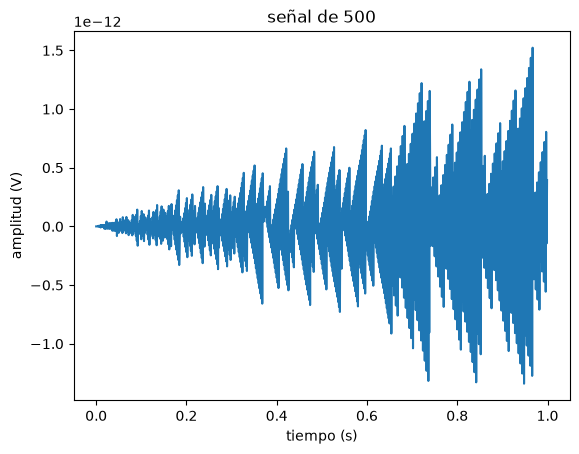

In [38]:
plt.plot(tt, xx)
plt.title("señal de "+str(ff)) #esto ultimo se lo agregue porque asi los graficos me pueden ir imprimiendo bien el tema de cual frecuencia estoy imprimiendo
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")
print(xx[:10])

Este grafico es critico, ya que estamos justisimo en nuestra frecuencia de Nyquist, fs/2, asi que estamos viendo lo que el teorema de Nyquist-Shannon nos define como la frecuencia más alta a la que nuestra señal es capturada fielmente, al estar en un punto tan critico cualquier ruido que sea capturado por nuestro generador de señales nos va a cambiar la forma del grafico. De hecho este no es el tipo de grafico que uno esperaria en 500hz, uno esperaria un grafico que oscile desde los dos extremos del seno, pero esto no sucedio ya que entro un error de punto flotante, de hecho en la esquina superior del grafico se puede apreciar el valor de los numeros del grafico, son numeros diminutos, esto es totalmente basura numerica, no es un grafico real de nuestra señal de hecho le agregue al final que imprima los primeros 10 valores de la funcion y se puede ver que aunque sea cercano a 0 no es 0, y este error claramente escala al avanzar en valores

Ahora comprobaremos con otras configuraciones para ver como cambian nuestros graficos

Text(0, 0.5, 'amplitud (V)')

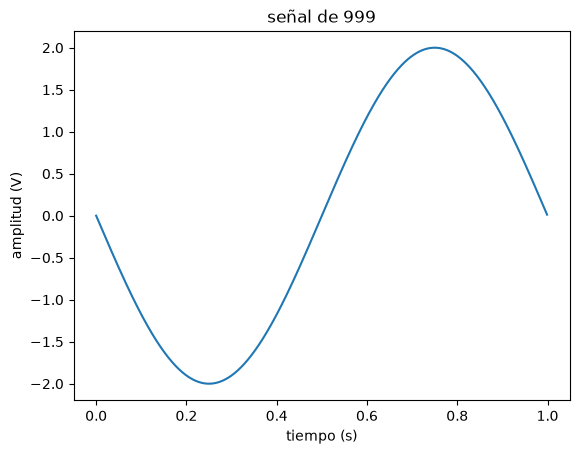

In [39]:
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 999 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!

tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff)
plt.plot(tt, xx)
plt.title("señal de "+str(ff)) #esto ultimo se lo agregue porque asi los graficos me pueden ir imprimiendo bien el tema de cual frecuencia estoy imprimiendo
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

Esta configuracion es muy interesante, ya que al haberse pasado de nuestra frecuencia maxima de Nyquist uno esperaria ver algo sin sentido en donde no se pueda nisiquiera apreciar la señal al ser 999hz en una señal que de por si tiene solo 1000 muestras, pero lo que sucede es que se produce el efecto de "Aliasing" el cual es un concepto teorico que nos dice que cada señal por encima de nuestra señal de Nyquist se ve plegada, pero hay que tener cuidado porque dependiendo de el valor de la resta de valores se define si esta repetida la señal como que fuese la normal pero dentro del intervalo o si se ve desfasada, el calculo se hace de la siguiente manera:
Primero vemos el modulo que es
$$
|ff - nf_s|
$$
con n siendo un numero entero,el resultado nos dice como se vera nuestra señal dentro del intervalo donde no salimos de la frecuencia de Nyquist, y la fase nos la da simplemente el signo de la resta sin modulo, el cual si es negativo se invierte la señal, esto se cumple en casi todos los casos, mas adelante veremos un caso donde esto no es tan lindo como aca

Text(0, 0.5, 'amplitud (V)')

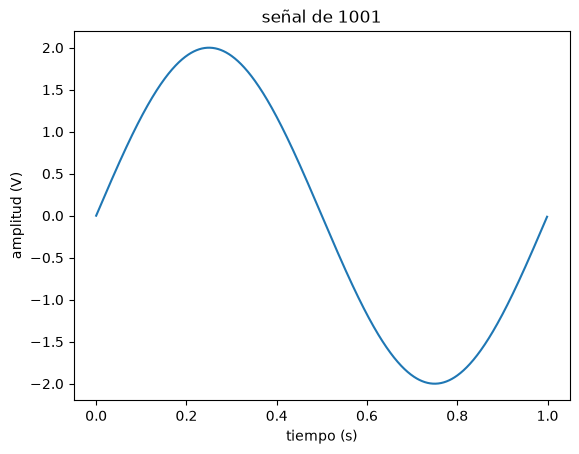

In [40]:
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 1001 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!

tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff)
plt.plot(tt, xx)
plt.title("señal de "+str(ff)) #esto ultimo se lo agregue porque asi los graficos me pueden ir imprimiendo bien el tema de cual frecuencia estoy imprimiendo
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

Aca se ve un caso muy parecido al anterior pero podemos ver como esta vez no se desfaso ya que la resta de $$ ff - nf_s $$ nos da un numero positivo

Text(0, 0.5, 'amplitud (V)')

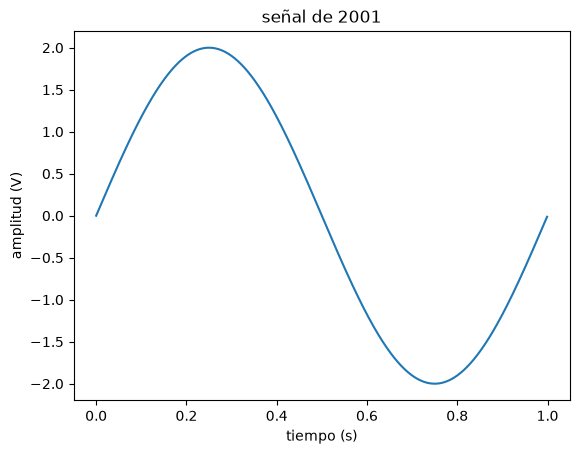

In [41]:
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 2001 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!

tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff)
plt.plot(tt, xx)
plt.title("señal de "+str(ff)) #esto ultimo se lo agregue porque asi los graficos me pueden ir imprimiendo bien el tema de cual frecuencia estoy imprimiendo
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

Aqui paso nuevamente lo del caso anterior ya que simplemente subimos un multiplo de Nyquist, simplemente incremento nuestra n

[ 0.00000000e+00 -4.89858720e-16 -9.79717439e-16 -1.46957616e-15
 -1.95943488e-15 -9.55472096e-15 -2.93915232e-15 -3.42901104e-15
 -3.91886976e-15 -1.86195832e-14]


Text(0, 0.5, 'amplitud (V)')

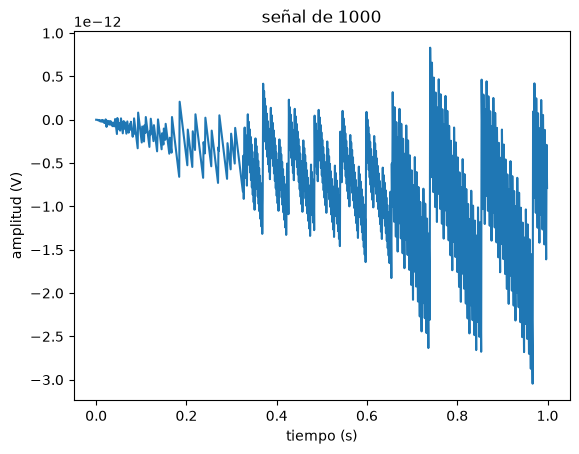

In [42]:
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 1000 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!

tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff)
plt.plot(tt, xx)
plt.title("señal de "+str(ff)) #esto ultimo se lo agregue porque asi los graficos me pueden ir imprimiendo bien el tema de cual frecuencia estoy imprimiendo
print(xx[:10])
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

Aqui sucedio algo muy interesante, uno esperaria por lo descrito anteriormente y la teoria que se vea simplemente como una señal de 0hz, osea una señal continua, pero esto no sucedio. Esto se debe a que al hacer la resta nos posiciona justamente sobre el valor de 500hz, lo cual como vimos anteriormente es un valor critico donde el ruido afecta, o en nuestro caso el error de punto flotante

Text(0, 0.5, 'amplitud (V)')

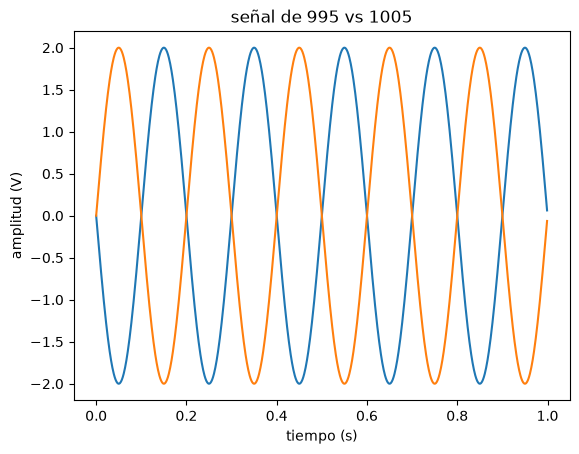

In [43]:
ff = 995
ff1 = 1005
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph)
plt.plot(tt, xx)

tt1, xx1 = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff1, ph=ph)
plt.plot(tt1, xx1)

plt.title("señal de " + str(ff) + " vs " + str(ff1))
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

En este grafico se puede ver claramente como se invirtio la fase, reafirmando lo hablado anteriormente

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 0.00000000e+00 -4.89858720e-16 -9.79717439e-16 -1.46957616e-15
 -1.95943488e-15 -9.55472096e-15 -2.93915232e-15 -3.42901104e-15
 -3.91886976e-15 -1.86195832e-14]


Text(0, 0.5, 'amplitud (V)')

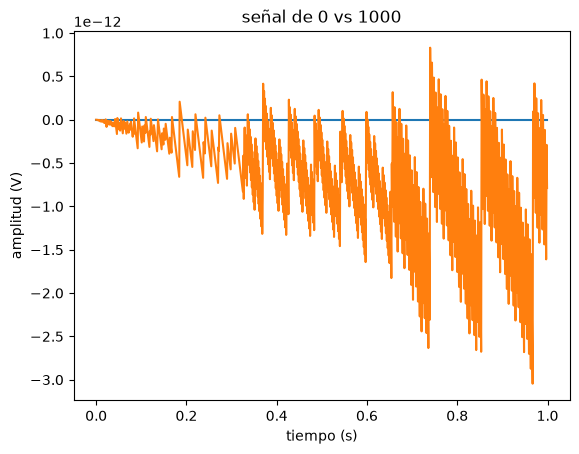

In [44]:
ff = 0
ff1 = 1000
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph)
plt.plot(tt, xx)

tt1, xx1 = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff1, ph=ph)
plt.plot(tt1, xx1)

plt.title("señal de " + str(ff) + " vs " + str(ff1))
print(xx[:10])
print(xx1[:10])
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

En este grafico se puede apreciar mucho mejor como la señal de 1000 aunque deberia ser igual que la de 0hz no lo es, esto sospecho que se debe a que al hacer el calculo de mi funcion aproxima pi, pero en 0 directamente no usa pi ya que la multiplicacion por 0 es 0, asi que por eso no comete errores, de hecho podemos ver en los primeros 10 valores que los de 0hz son exactamente 0, ya que el sen(0) esta representado exactamente en punto flotante

**Otras señales**

Text(0, 0.5, 'amplitud (V)')

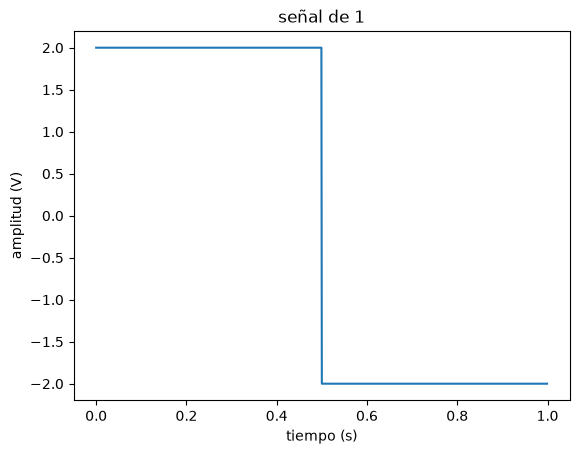

In [45]:
#de aqui para abajo recien edito
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 1 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!

def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    xx = (vmax * signal.square(2 * np.pi * ff * np.arange(nn)/fs + ph)) + dc
    tt = np.arange(N)/fs
    return (tt,xx)

tt, xx = mi_funcion_cuadrada( vmax = vmax, dc = dc, ff = ff)

plt.plot(tt, xx)
plt.title("señal de "+str(ff))
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

Aca al ser una señal cuadrada simplemente se ven los limites de la señal, pero se mantiene todo el concepto teorico que vimos con el seno, ya que no depende de la forma de la señal

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
[ 2.  2.  2.  2.  2. -2.  2.  2.  2. -2.]
2.0 2.0
2.0 -2.0


Text(0, 0.5, 'amplitud (V)')

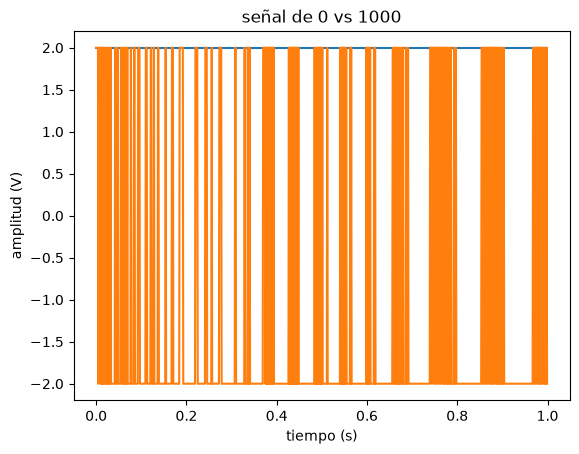

In [46]:
#de aqui para abajo recien edito
vmax = 2 #simplemente mi amplitud maxima
dc = 0 # es mi desplazamiento, si es positivo me lo sube, negativo me lo baja
ff = 0 #frecuencia variable
ph = 0 #me parece q la fase ojo q es radianes!!
ff1 = 1000

def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    xx = (vmax * signal.square(2 * np.pi * ff * np.arange(nn)/fs + ph)) + dc
    tt = np.arange(N)/fs
    return (tt,xx)

tt, xx = mi_funcion_cuadrada( vmax = vmax, dc = dc, ff = ff)

plt.plot(tt, xx)

tt1, xx1 = mi_funcion_cuadrada( vmax = vmax, dc = dc, ff = ff1)

plt.plot(tt1, xx1)
plt.title("señal de "+str(ff)+ " vs "+str(ff1))
print(xx[:10])
print(xx1[:10])
print(np.max(xx), np.min(xx))
print(np.max(xx1), np.min(xx1))
plt.xlabel("tiempo (s)")
plt.ylabel("amplitud (V)")

Este caso es muy interesante porque se puede apreciar como vuelve a suceder el error de punto flotante pero en este caso entre los dos valores en los que oscila la señal

En conclusion en esta experimetacion se pudo comprobar como se cumple en la practica los conceptos teoricos como el teorema de Nyquist, se comprobo que la frecuencia de Nyquist no es solo un limite teorico al que podemos llegar, sino que tambien es un punto critico, donde cualquier ruido nos puede afectar el grafico, en este caso al hacerlo en simulacion por python fue muy interesante porque el ruido no vino necesariamente de factores externos como la estatica por ejemplo que uno esperaria encontrarse en la practica. Tambien comprobamos que la validez de estos conceptos no se ve regida por la forma de la señal. Esto nos hace entender que todo sistema debereia llevar un filtro anti-aisling para evitar este tipo de problemas. 